<a href="https://colab.research.google.com/github/ishikabeniwal/CSET343/blob/main/CSET343_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb pydicom pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import wfdb
from collections import Counter

In [ ]:
# Load dataset
df = pd.read_csv("heart.csv")     # Upload heart.csv in Colab

# Display first 5 rows
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    0   0       129   188    0        0       97      0      3.7      0   
1   43    0   1       177   305    1        0      185      1      5.0      0   
2   50    1   1       121   321    1        0       94      1      0.6      1   
3   63    0   3       104   267    1        2      163      0      4.4      0   
4   43    0   3       129   242    1        0      165      1      1.3      1   

   ca  thal  target  
0   0     3       0  
1   1     7       1  
2   2     3       1  
3   1     6       0  
4   0     7       0  


In [ ]:
print(df.info())
print(df.describe())

# Missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       50 non-null     int64  
 1   sex       50 non-null     int64  
 2   cp        50 non-null     int64  
 3   trestbps  50 non-null     int64  
 4   chol      50 non-null     int64  
 5   fbs       50 non-null     int64  
 6   restecg   50 non-null     int64  
 7   thalach   50 non-null     int64  
 8   exang     50 non-null     int64  
 9   oldpeak   50 non-null     float64
 10  slope     50 non-null     int64  
 11  ca        50 non-null     int64  
 12  thal      50 non-null     int64  
 13  target    50 non-null     int64  
dtypes: float64(1), int64(13)
memory usage: 5.6 KB
None
             age        sex        cp    trestbps        chol        fbs  \
count  50.000000  50.000000  50.00000   50.000000   50.000000  50.000000   
mean   53.220000   0.500000   1.48000  135.720000  236.860000   0

In [ ]:
# 0 = No disease, 1 = Disease
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

print(df["target"].value_counts())

target
0    25
1    25
Name: count, dtype: int64


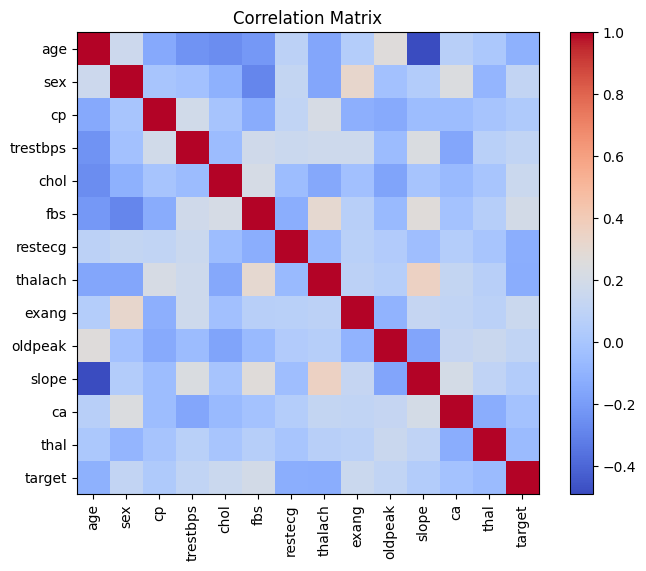

In [ ]:
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 0.3
[[1 4]
 [3 2]]


In [ ]:
with open("patient_dataset.csv", "r") as file:
    text = file.read()

print(text)

patient_id,age,sex,systolic_bp,diastolic_bp,heart_rate,temperature_f,fatigue,headache
P001,45,Female,132,84,78,98.4,1,1
P002,52,Male,145,92,82,98.7,1,0
P003,38,Female,118,76,72,98.1,0,1
P004,61,Male,151,95,88,99.0,1,1
P005,29,Female,110,70,69,98.2,0,0
P006,47,Male,138,88,81,98.6,1,1
P007,55,Female,129,82,76,98.3,1,0
P008,34,Male,124,79,74,98.5,0,0
P009,68,Female,158,96,90,99.1,1,1
P010,41,Male,136,86,79,98.4,0,1



In [ ]:
# Convert into lowercase words

words = text.lower().split()

print(words)

['patient_id,age,sex,systolic_bp,diastolic_bp,heart_rate,temperature_f,fatigue,headache', 'p001,45,female,132,84,78,98.4,1,1', 'p002,52,male,145,92,82,98.7,1,0', 'p003,38,female,118,76,72,98.1,0,1', 'p004,61,male,151,95,88,99.0,1,1', 'p005,29,female,110,70,69,98.2,0,0', 'p006,47,male,138,88,81,98.6,1,1', 'p007,55,female,129,82,76,98.3,1,0', 'p008,34,male,124,79,74,98.5,0,0', 'p009,68,female,158,96,90,99.1,1,1', 'p010,41,male,136,86,79,98.4,0,1']


In [ ]:
from collections import Counter

frequency = Counter(words)

print(frequency)

Counter({'patient_id,age,sex,systolic_bp,diastolic_bp,heart_rate,temperature_f,fatigue,headache': 1, 'p001,45,female,132,84,78,98.4,1,1': 1, 'p002,52,male,145,92,82,98.7,1,0': 1, 'p003,38,female,118,76,72,98.1,0,1': 1, 'p004,61,male,151,95,88,99.0,1,1': 1, 'p005,29,female,110,70,69,98.2,0,0': 1, 'p006,47,male,138,88,81,98.6,1,1': 1, 'p007,55,female,129,82,76,98.3,1,0': 1, 'p008,34,male,124,79,74,98.5,0,0': 1, 'p009,68,female,158,96,90,99.1,1,1': 1, 'p010,41,male,136,86,79,98.4,0,1': 1})


In [ ]:
print("Top 5 words:")
print(frequency.most_common(5))

Top 5 words:
[('patient_id,age,sex,systolic_bp,diastolic_bp,heart_rate,temperature_f,fatigue,headache', 1), ('p001,45,female,132,84,78,98.4,1,1', 1), ('p002,52,male,145,92,82,98.7,1,0', 1), ('p003,38,female,118,76,72,98.1,0,1', 1), ('p004,61,male,151,95,88,99.0,1,1', 1)]


Original Size: (512, 512)


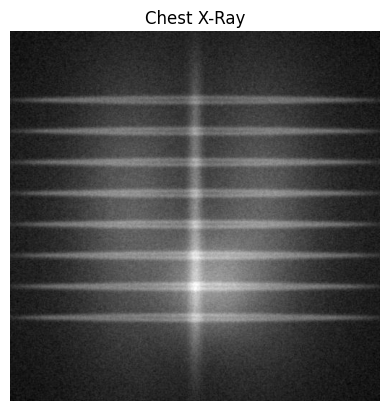

In [ ]:
img = Image.open("P006_chest_xray.jpg")     # Upload image

print("Original Size:", img.size)

plt.imshow(img, cmap="gray")
plt.title("Chest X-Ray")
plt.axis("off")
plt.show()

New Size: (224, 224)


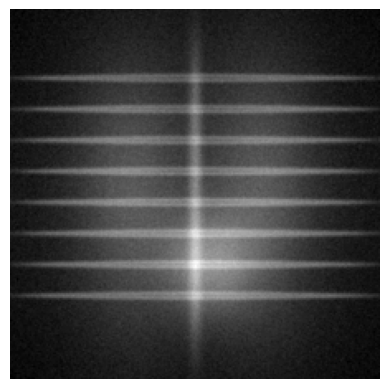

In [ ]:
resized = img.resize((224,224))

print("New Size:", resized.size)

plt.imshow(resized, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
print(img.format)
print(img.mode)
print(img.size)

JPEG
L
(512, 512)
